# 00 — Exploratory analysis and preprocessing
**Multivariate forecasting of total PV generation on the SENELEC grid with PatchTST**

| Item | Choice |
|---|---|
| Data | `energie.xlsx` — SENELEC hourly log, 01/01/2019 → 09/05/2023 |
| Target | `PV_total` (MW) = sum of the 11 PV plants |
| Forbidden inputs (R4) | individual PV productions, `Total_unites`, `RI`, `RGI_*` (they contain PV) |
| Covariates | grid context (3), cyclic (6), solar geometry (2) |
| Split (R1) | Train 2019–2021 · Val 01–09/2022 · Test 10/2022–05/2023 |

**Outline of the notebook**
1. Loading and check of the hourly grid
2. Construction of the target (clipping, causal imputation, per-plant traceability)
3. Missing values
4. Seasonality: daily profile, ACF, periodogram
5. Non-stationarity: commissionings and apparent capacity
6. Covariates: cyclic, solar geometry, grid context
7. Correlations
8. Temporal split and normalisation (leakage-free)
9. Conclusions for modelling

In [1]:
# --- Environment shared by all notebooks ------------------------------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import patchtst_pv as m                # core module of the study (fully commented)
import figure_style as fs         # visual style of the paper's figures
fs.apply()
pd.set_option("display.width", 160, "display.max_columns", 30, "display.precision", 4)

## 1. Loading and check of the hourly grid

In [2]:
raw = pd.read_excel(m.DATA_PATH)
print(f"Rows in the file: {len(raw):,} | columns: {raw.shape[1]}")
print(f"Period: {raw['Horodatage_debut'].min()} → {raw['Horodatage_debut'].max()}")
gaps = raw['Horodatage_debut'].diff().value_counts()
print("Gaps between consecutive timestamps:"); print(gaps.to_string())
log = m.load_log()
print(f"Complete hourly grid: {len(log):,} h → {log['Heure'].isna().sum()} hours missing from the file (NaN)")

Rows in the file: 37,872 | columns: 51
Period: 2019-01-01 00:00:00 → 2023-05-09 23:00:00
Gaps between consecutive timestamps:
Horodatage_debut
0 days 01:00:00    37863
1 days 01:00:00        6
3 days 01:00:00        2


Complete hourly grid: 38,160 h → 288 hours missing from the file (NaN)


> **Reading.** The time step is hourly. The 288 missing hours correspond to 8 jumps of one or three days. The grid is
> completed to remain regular (a requirement of windowing); the added hours are imputed causally.

## 2. Construction of the target `PV_total`

In [3]:
ds = m.build_dataset(cache=False)          # complete pipeline (see module, sections 1–3)
tab = ds.table
print(f"Solar offset estimated on Train: {ds.solar_offset_h:+.2f} h")
ds.target_diagnostics

Solar offset estimated on Train: +0.50 h


,plant,commissioning,last_record,threshold_MW,clipped_values,imputed_gaps,mean_MW,max_MW
0,PV-Mbour,2019-01-01 07:00:00,2023-05-09 18:00:00,22.73,14,1032,3.97,20.38
1,PV-CICAD,2019-01-01 07:00:00,2023-04-11 19:00:00,4.37,36,710,0.26,4.00
2,PV Kahone,2019-01-01 06:00:00,2021-01-25 18:00:00,19.08,1,454,1.57,16.15
3,PV ERS Kahone,2021-01-26 07:00:00,2023-05-09 19:00:00,18.09,13,244,1.97,17.14
4,PV Scaling Kahone,2021-01-26 12:00:00,2023-05-09 18:00:00,39.34,1,779,3.21,34.16
5,PV Kael Touba,2021-03-26 07:00:00,2023-05-09 18:00:00,30.20,1,200,2.80,29.62
6,PV-Bokhol,2019-01-01 07:00:00,2023-05-09 19:00:00,23.10,11,901,4.16,23.09
7,PV Mékhé Mérina,2019-01-01 07:00:00,2023-05-09 18:00:00,24.28,24,522,5.63,20.60
8,PV S Mekhe Santhiou,2019-01-01 07:00:00,2023-05-09 19:00:00,25.16,0,1066,5.58,24.72
9,PV DIASS,2019-06-12 06:00:00,2023-05-09 19:00:00,22.32,1,829,3.45,20.97


**Rules applied to each plant** (module, function `build_target`):
- clipping threshold = 1.2 × 99.9 % quantile **computed on Train**: higher values (e.g. 958 MW at Mbour) are entry errors;
- outside the period of existence (before commissioning, after decommissioning): production is zero;
- gaps ≤ 3 h: linear interpolation; longer gaps: mean of the same hour over the **previous** 7 days.

The individual productions are only used to build the target: they are **never** model inputs.

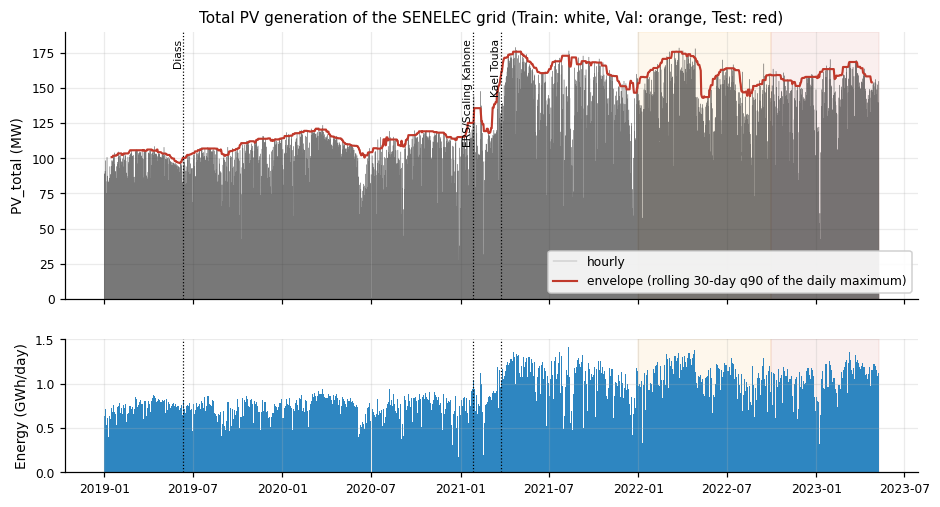

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
ax[0].plot(tab.index, tab[m.TARGET], lw=0.25, color=fs.COLORS["observed"], alpha=0.6, label="hourly")
dmax = tab[m.TARGET].resample("D").max()
ax[0].plot(dmax.index, dmax.rolling(30, center=True).quantile(0.9), color=fs.COLORS["model"], lw=1.4,
           label="envelope (rolling 30-day q90 of the daily maximum)")
events = {"Diass": "2019-06-12", "ERS/Scaling Kahone": "2021-01-26", "Kael Touba": "2021-03-26"}
for k, d in events.items():
    for a in ax: a.axvline(pd.Timestamp(d), color="k", ls=":", lw=0.8)
    ax[0].text(pd.Timestamp(d), 185, k, rotation=90, va="top", ha="right", fontsize=7)
for a in ax:
    a.axvspan(m.VAL_START, m.TEST_START, color=fs.COLORS["val"], alpha=0.08)
    a.axvspan(m.TEST_START, tab.index[-1], color=fs.COLORS["test"], alpha=0.08)
ax[0].set_ylabel("PV_total (MW)"); ax[0].legend(loc="lower right", framealpha=0.9); ax[0].set_ylim(0, 190)
energy = tab[m.TARGET].resample("D").sum() / 1000
ax[1].bar(energy.index, energy.values, width=1, color=fs.COLORS["mean"])
ax[1].set_ylabel("Energy (GWh/day)")
ax[0].set_title("Total PV generation of the SENELEC grid (Train: white, Val: orange, Test: red)")
fs.save(fig, "fig01_pv_total_series")

## 3. Missing values (raw file)

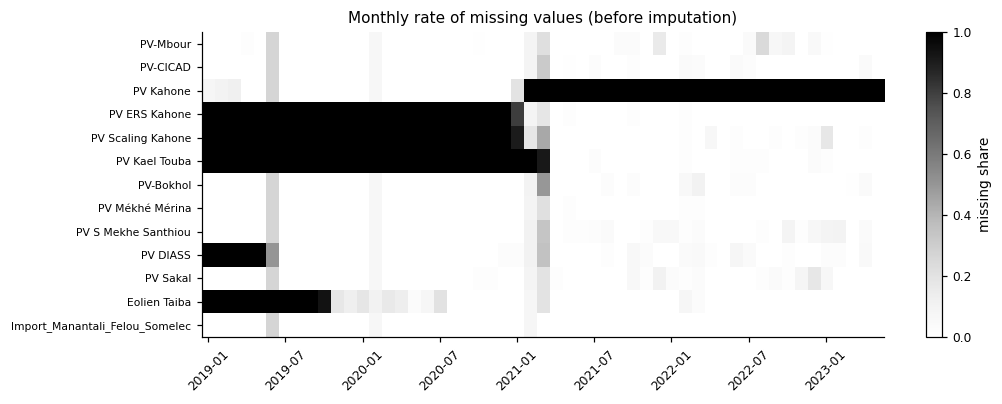

PV-Mbour                           2.7
PV-CICAD                           1.8
PV Kahone                         53.6
PV ERS Kahone                     48.2
PV Scaling Kahone                 49.6
PV Kael Touba                     51.7
PV-Bokhol                          2.3
PV Mékhé Mérina                    1.3
PV S Mekhe Santhiou                2.8
PV DIASS                          12.4
PV Sakal                           2.5
Eolien Taiba                      21.9
Import_Manantali_Felou_Somelec     0.8


In [5]:
columns = m.PV_COLUMNS + ["Eolien Taiba", "Import_Manantali_Felou_Somelec"]
missing = log[columns].isna().groupby(log.index.to_period("M")).mean().T
fig, ax = plt.subplots(figsize=(10, 3.6))
im = ax.imshow(missing.values, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax.set_yticks(range(len(columns)), columns, fontsize=7)
xt = range(0, missing.shape[1], 6); ax.set_xticks(list(xt), [str(missing.columns[i]) for i in xt], rotation=45)
fig.colorbar(im, ax=ax, label="missing share")
ax.set_title("Monthly rate of missing values (before imputation)"); ax.grid(False)
fs.save(fig, "fig02_missing_values")
print((log[columns].isna().mean() * 100).round(1).to_string())

> **Reading.** The missing blocks of `PV Kahone`, `PV ERS Kahone`, `PV Scaling Kahone` and `PV Kael Touba` are **structural**:
> they cover the periods when the plant did not exist yet (or any more). The Kahone plant was replaced by ERS and
> Scaling Kahone on 26/01/2021. These periods are zero by definition; they are not a matter of imputation.

## 4. Seasonality

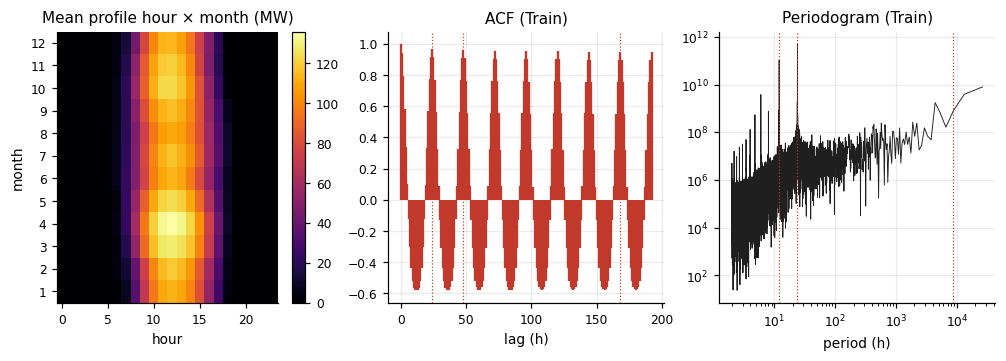

{1: np.float64(0.9416), 23: np.float64(0.917), 24: np.float64(0.9699), 25: np.float64(0.916), 48: np.float64(0.962), 168: np.float64(0.9494)}
Dominant period (h): 24.0


In [6]:
from statsmodels.tsa.stattools import acf
y = tab[m.TARGET]
fig, ax = plt.subplots(1, 3, figsize=(11, 3.2))
prof = y.groupby([y.index.month, y.index.hour]).mean().unstack()
im = ax[0].imshow(prof.values, aspect="auto", cmap="inferno", origin="lower")
ax[0].set_xlabel("hour"); ax[0].set_ylabel("month"); ax[0].set_yticks(range(12), range(1, 13))
ax[0].set_title("Mean profile hour × month (MW)"); fig.colorbar(im, ax=ax[0]); ax[0].grid(False)
r = acf(y[: ds.i_val], nlags=24 * 8, fft=True)
ax[1].stem(range(len(r)), r, markerfmt=" ", basefmt=" ")
for k in (24, 48, 168): ax[1].axvline(k, color=fs.COLORS["model"], ls=":", lw=0.8)
ax[1].set_title("ACF (Train)"); ax[1].set_xlabel("lag (h)")
f = np.fft.rfftfreq(ds.i_val, d=1); p = np.abs(np.fft.rfft(y[: ds.i_val] - y[: ds.i_val].mean())) ** 2
ax[2].loglog(1 / f[1:], p[1:], lw=0.6, color=fs.COLORS["observed"])
for T in (12, 24, 24 * 365.25): ax[2].axvline(T, color=fs.COLORS["model"], ls=":", lw=0.8)
ax[2].set_title("Periodogram (Train)"); ax[2].set_xlabel("period (h)")
fs.save(fig, "fig03_seasonality")
print({k: round(r[k], 4) for k in (1, 23, 24, 25, 48, 168)})
print("Dominant period (h):", round(1 / f[1:][np.argmax(p[1:])], 2))

> **Reading.** The daily cycle dominates (ACF(24) ≈ 0.95, periodogram peak at 24 h, harmonic at 12 h).
> The period is indeed 24 steps: the period-27 anomaly found in the former file `production.xlsx` is absent here.
> The annual cycle modulates the amplitude: maximum in March–May, trough in August–September (rainy season and monsoon cloudiness).

## 5. Non-stationarity: growth of the installed fleet

In [7]:
yearly = y.groupby(y.index.year).agg(["mean", "max"])
yearly["q99_daily_max"] = y.resample("D").max().groupby(lambda d: d.year).quantile(0.99)
yearly.columns = ["mean (MW)", "maximum (MW)", "q99 of the daily max (MW)"]
display(yearly.round(1))
print("Growth of the mean 2019 → 2022: %+.0f %%" % (100 * (yearly.iloc[3, 0] / yearly.iloc[0, 0] - 1)))

,mean (MW),maximum (MW),q99 of the daily max (MW)
timestamp,,,
2019,29.9,115.8,114.2
2020,30.8,123.6,120.6
2021,42.1,179.0,176.1
2022,44.0,178.6,176.0
2023,45.7,170.4,169.7


Growth of the mean 2019 → 2022: +47 %


> **Reading.** Between 2019 and 2022, mean production rises by 47 % as plants are commissioned.
> The series is therefore **not level-stationary**, which justifies the per-window reversible normalisation (RevIN)
> of the model and the evaluation of the **drift** over one month of forecasting without re-training.

## 6. Covariates

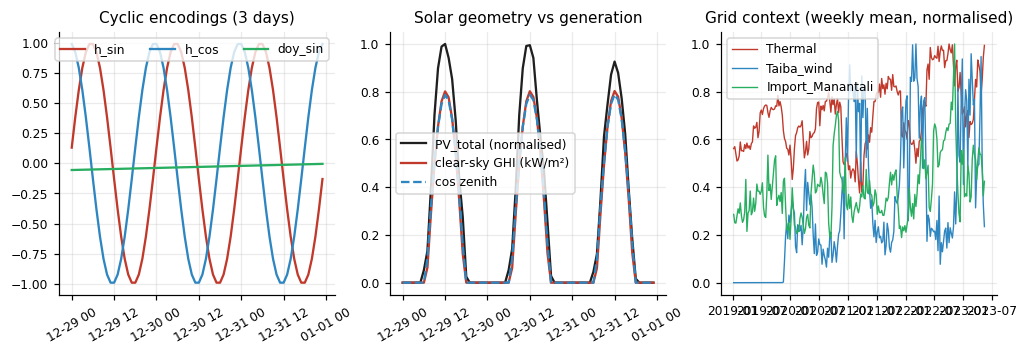

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))
j = slice(ds.i_val - 24 * 3, ds.i_val)
t = tab.index[j]
ax[0].plot(t, tab["h_sin"].values[j], label="h_sin"); ax[0].plot(t, tab["h_cos"].values[j], label="h_cos")
ax[0].plot(t, tab["doy_sin"].values[j], label="doy_sin"); ax[0].legend(ncol=3); ax[0].set_title("Cyclic encodings (3 days)")
ax[0].tick_params(axis="x", rotation=30)
yn = tab[m.TARGET].values[j] / tab[m.TARGET].values[j].max()
ax[1].plot(t, yn, color=fs.COLORS["observed"], label="PV_total (normalised)")
ax[1].plot(t, tab["ghi_clear_sky"].values[j] / 1000, color=fs.COLORS["model"], label="clear-sky GHI (kW/m²)")
ax[1].plot(t, tab["cos_zenith"].values[j], ls="--", color=fs.COLORS["mean"], label="cos zenith")
ax[1].legend(); ax[1].set_title("Solar geometry vs generation"); ax[1].tick_params(axis="x", rotation=30)
for c in m.GRID_CHANNELS:
    s = tab[c].resample("W").mean(); ax[2].plot(s.index, s / s.max(), label=c, lw=0.9)
ax[2].legend(); ax[2].set_title("Grid context (weekly mean, normalised)")
fs.save(fig, "fig04_covariates")

**Why these covariates?**
- **Cyclic** (sin/cos of the hour, the day of year, the day of week): they ensure continuity at the boundaries
  (23:00 → 00:00, 31/12 → 01/01). The day of week has no physical link with irradiance: it serves as a **negative control** in the XAI analysis.
- **Solar geometry** (pvlib): cosine of the zenith angle and clear-sky irradiance (Haurwitz), at the barycentre of the plants.
  They are **deterministic**, hence known without error at any horizon: they are the only variables available for the **future**.
- **Grid context**: aggregated thermal production, Taiba wind, Manantali import. They are only used over the **past** window,
  as a "weather proxy" (net demand and the wind regime reflect the state of the atmosphere).

## 7. Correlations

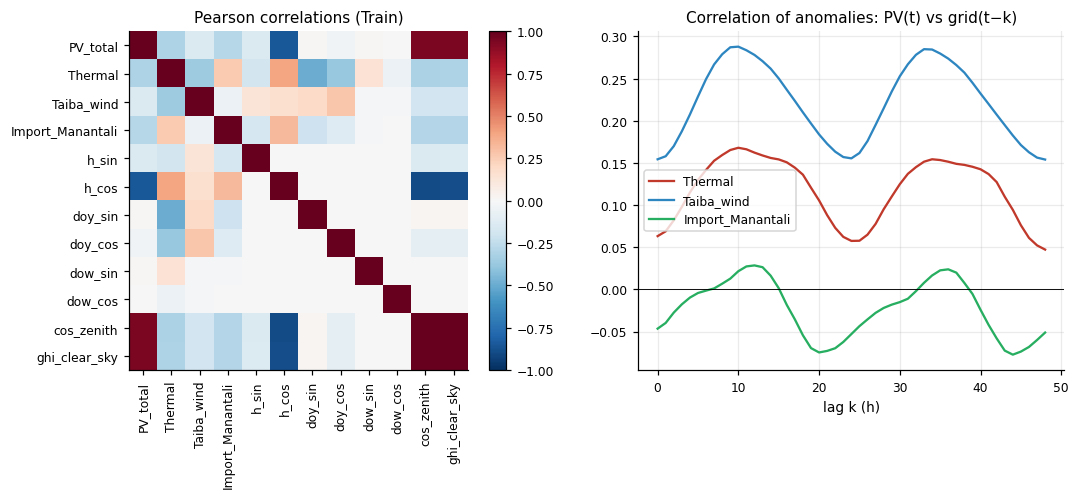

PV_total            1.000
Thermal            -0.305
Taiba_wind         -0.145
Import_Manantali   -0.286
h_sin              -0.141
h_cos              -0.847
doy_sin             0.010
doy_cos            -0.033
dow_sin             0.014
dow_cos            -0.004
cos_zenith          0.944
ghi_clear_sky       0.945


In [9]:
cor = tab.iloc[: ds.i_val].corr()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im = ax[0].imshow(cor.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax[0].set_xticks(range(len(cor)), cor.columns, rotation=90); ax[0].set_yticks(range(len(cor)), cor.columns)
fig.colorbar(im, ax=ax[0]); ax[0].set_title("Pearson correlations (Train)"); ax[0].grid(False)
# cross-correlation target(t) vs grid(t-k) on the anomalies (mean daily-seasonal cycle removed)
anomaly = lambda s: s - s.groupby([s.index.dayofyear, s.index.hour]).transform("mean")
ya = anomaly(tab[m.TARGET].iloc[: ds.i_val])
for c in m.GRID_CHANNELS:
    xa = anomaly(tab[c].iloc[: ds.i_val])
    cc = [ya.corr(xa.shift(k)) for k in range(0, 49)]
    ax[1].plot(range(0, 49), cc, label=c)
ax[1].axhline(0, color="k", lw=0.6); ax[1].legend(); ax[1].set_xlabel("lag k (h)")
ax[1].set_title("Correlation of anomalies: PV(t) vs grid(t−k)")
fs.save(fig, "fig05_correlations")
print(cor[m.TARGET].round(3).to_string())

> **Reading.** The target is strongly correlated with solar geometry (cos zenith, clear sky) and the hourly encoding.
> Once the mean cycle is removed, the production anomalies show only a **weak** correlation with the past grid
> context. A limited contribution of the grid channels can therefore be expected; the study quantifies it (Config 3 and XAI).

## 8. Temporal split and normalisation (leakage-free)

In [10]:
seg = pd.DataFrame({
    "segment": ["Train", "Validation", "Test"],
    "start": [tab.index[0], tab.index[ds.i_val], tab.index[ds.i_test]],
    "end": [tab.index[ds.i_val - 1], tab.index[ds.i_test - 1], tab.index[-1]],
    "hours": [ds.i_val, ds.i_test - ds.i_val, len(tab) - ds.i_test],
})
seg["mean PV (MW)"] = [tab[m.TARGET].iloc[a:b].mean() for a, b in [(0, ds.i_val), (ds.i_val, ds.i_test), (ds.i_test, len(tab))]]
display(seg)
# Checks of the golden rules
assert tab.index[ds.i_val - 1] < m.VAL_START <= tab.index[ds.i_val]            # R1
assert np.allclose(ds.mean, tab.iloc[: ds.i_val].mean().values)               # R2: normalisation = Train
assert not set(m.PV_COLUMNS + m.EXCLUDED_COLUMNS) & set(tab.columns)          # R4
print("Rules R1, R2, R4 verified. Model channels:", m.CHANNELS)

,segment,start,end,hours,mean PV (MW)
0,Train,2019-01-01,2021-12-31 23:00:00,26304,34.2683
1,Validation,2022-01-01,2022-09-30 23:00:00,6552,44.5920
2,Test,2022-10-01,2023-05-09 23:00:00,5304,44.2753


Rules R1, R2, R4 verified. Model channels: ['PV_total', 'Thermal', 'Taiba_wind', 'Import_Manantali', 'h_sin', 'h_cos', 'doy_sin', 'doy_cos', 'dow_sin', 'dow_cos', 'cos_zenith', 'ghi_clear_sky']


## 9. Conclusions for modelling

1. **Clean and traceable target.** 11 plants, 107 outliers clipped, gaps imputed causally, out-of-service periods set to zero.
2. **Dominant 24 h cycle** and annual amplitude seasonality: the cyclic encodings and solar geometry describe the **deterministic** part;
   the model must learn the **random** part (cloudiness), carried by the recent history of the target.
3. **Level non-stationarity** (+47 % between 2019 and 2022): per-window normalisation (RevIN) and drift test.
4. **Daily persistence will be a hard baseline**: ACF(24) = 0.95.
5. The dataset (12 channels) is cached for notebooks 01 to 05.